# QoQ-Med-VL-7B inference walkthrough

What does one inference call to QoQ-Med-VL-7B look like, and how do many of them stack into the KPSC zero-shot eval pipeline (`scripts/eval_qoq_med_kpsc800.py`)?

Everything below runs on a single synthetic image — no real MRI data needed. The pipeline pieces (`slice_to_pil_minmax`, `sample_answers`, `slice_prob_from_answers`, `aggregate`) all come from `src/qoq_eval_utils.py`, so the cells here are the exact functions the production script uses.

Run this on a GPU node (A100 / A6000). The model is ≈14 GB in bf16.

## 1. Setup

In [20]:
import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image

REPO = Path.cwd().parent          # this notebook lives in <repo>/notebooks/
sys.path.insert(0, str(REPO / "src"))
import qoq_eval_utils as qu

torch.manual_seed(0)
np.random.seed(0)

## 2. Load model + processor

Same `MODEL_ID` the eval script uses.

In [21]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

MODEL_ID = "ddvd233/QoQ-Med-VL-7B"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map="mps"
).eval()

print(f"params: {sum(p.numel() for p in model.parameters()) / 1e9:.1f} B")
print(f"vocab size: {model.config.text_config.vocab_size}")
print(f"device: {model.device}")


Loading weights: 100%|██████████| 729/729 [00:31<00:00, 22.98it/s] 


params: 8.3 B
vocab size: 152064
device: mps:0


## 3. Build a dummy "slice"

A 256×256 grayscale circle on a gradient — enough for the model to describe *something*. In the real pipeline this comes from `slice_to_pil_minmax(vol[s, m])` where `vol[s, m]` is one 2D modality slice of a subject's volume.

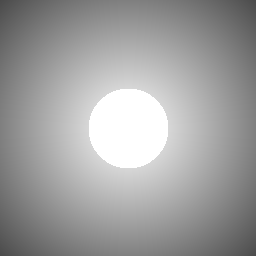

In [22]:
H = W = 256
yy, xx = np.mgrid[:H, :W]
r = np.hypot(yy - H/2, xx - W/2)
slice2d = ((H - r) / H * 255).clip(0, 255)
slice2d += 80 * (r < 40)                          # bright blob in the middle
slice2d = slice2d.clip(0, 255).astype(np.uint8)
img = Image.fromarray(np.stack([slice2d] * 3, axis=-1), mode="RGB")
img

Equivalent to `qu.slice_to_pil_minmax(slice2d_float32)` — same per-array min/max rescale to uint8, same RGB triple.

## 4. Prompt + chat formatting

The prompt template lives in `qu.PROMPTS`. The processor's `apply_chat_template` wraps `(image, text)` in Qwen's chat format and appends an assistant-turn marker so the next token is the model's reply.

In [23]:
prompt = qu.PROMPTS["wmd"].format(modality="T2")
print(prompt)

You are a radiologist. This is a 2D axial MRI slice of a human brain (T2-weighted). Is there evidence of white matter disease in this slice? Answer with a single word: Yes or No.


In [24]:
chat = [{"role": "user", "content": [
    {"type": "image", "image": img},
    {"type": "text",  "text":  prompt},
]}]
chat_text = processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
print(chat_text)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>You are a radiologist. This is a 2D axial MRI slice of a human brain (T2-weighted). Is there evidence of white matter disease in this slice? Answer with a single word: Yes or No.<|im_end|>
<|im_start|>assistant



In [25]:
inputs = processor(text=[chat_text], images=[img], padding=True, return_tensors="pt").to(model.device)
{k: tuple(v.shape) for k, v in inputs.items() if hasattr(v, "shape")}

{'input_ids': (1, 148),
 'attention_mask': (1, 148),
 'mm_token_type_ids': (1, 148),
 'pixel_values': (324, 1176),
 'image_grid_thw': (1, 3)}

## 5. One sampled generation

`model.generate(do_sample=True, max_new_tokens=1)` returns the prompt tokens followed by one new token — we strip the prompt and decode.

In [26]:
with torch.inference_mode():
    out = model.generate(
        **inputs,
        do_sample=True,
        temperature=0.7,
        max_new_tokens=1,
        pad_token_id=processor.tokenizer.pad_token_id or processor.tokenizer.eos_token_id,
    )
prompt_len = inputs["input_ids"].shape[1]
new_tokens = out[:, prompt_len:]
decoded = processor.tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
print("new token id:", new_tokens.tolist())
print("decoded:", decoded)

new token id: [[2753]]
decoded: ['No']


## 6. Repeat N times → slice probability

Identical to what the eval script does per slice. `qu.sample_answers` loops `model.generate` N times; `qu.slice_prob_from_answers` collapses the list of answers into a probability:

- contains `"yes"` (and no `"no"`) → 1.0
- contains `"no"`  (and no `"yes"`) → 0.0
- neither (or both) → 0.5

The slice probability is the mean over the N votes.

In [27]:
N = 5
answers = qu.sample_answers(
    model, processor, batch=[(img, "T2")],
    n_samples=N, temperature=0.7,
    prompt_template=qu.PROMPTS["wmd"],
)[0]
print("raw answers:", answers)
print(f"slice P(Yes) = {qu.slice_prob_from_answers(answers):.3f}  (N={N})")

raw answers: ['No', 'No', 'No', 'No', 'No']
slice P(Yes) = 0.000  (N=5)


If you wanted higher precision, bump `N`. For the dummy image you'll see mostly 'No' — there's no anatomy that looks like white matter disease, so the model votes "No" and `P(Yes)` is near 0.

## 6b. Alternative: probability from token logits (what we *used to* do)

Instead of generating N times, we can do **one** forward pass and inspect what the model "wanted to say" — its distribution over the very next token, restricted to `"Yes"` vs `"No"`.

This is what the previous `score_batch` did. It's cheaper (1 pass instead of N) but throws away information when the model would have started its reply with something other than Yes/No.

In [28]:
import torch.nn.functional as F

yes_id, no_id, yn_info = qu.resolve_yes_no_ids(processor.tokenizer)
print("yes/no tokens:", yn_info)

with torch.inference_mode():
    out = model(**inputs)
logits = out.logits
print("logits shape:", tuple(logits.shape))

last_pos = inputs["attention_mask"].sum(1) - 1
last_logits = logits[torch.arange(logits.size(0)), last_pos]

full_probs = F.softmax(last_logits.float(), dim=-1)
top5 = torch.topk(full_probs, k=5, dim=-1)
print("\ntop-5 candidates for the model's first reply token:")
for prob, tok_id in zip(top5.values[0].tolist(), top5.indices[0].tolist()):
    tok = processor.tokenizer.decode([tok_id])
    print(f"  {prob:.3f}  {tok!r}  (id={tok_id})")

yn_logits = torch.stack([last_logits[:, yes_id], last_logits[:, no_id]], dim=-1)
yn_probs  = F.softmax(yn_logits.float(), dim=-1)

print(f"\nrestricted P(Yes) = {yn_probs[0, 0].item():.3f}")
print(f"restricted P(No)  = {yn_probs[0, 1].item():.3f}")

print(f"\nfull-vocab P(token=Yes) = {full_probs[0, yes_id].item():.3f}")
print(f"full-vocab P(token=No)  = {full_probs[0, no_id].item():.3f}")
print(f"mass on {{Yes, No}}     = {(full_probs[0, yes_id] + full_probs[0, no_id]).item():.3f}")


yes/no tokens: {'yes': 'Yes', 'no': 'No', 'yes_id': 9454, 'no_id': 2753}
logits shape: (1, 148, 152064)

top-5 candidates for the model's first reply token:
  0.998  'No'  (id=2753)
  0.002  'Yes'  (id=9454)
  0.000  'NO'  (id=8996)
  0.000  'None'  (id=4064)
  0.000  'N'  (id=45)

restricted P(Yes) = 0.002
restricted P(No)  = 0.998

full-vocab P(token=Yes) = 0.002
full-vocab P(token=No)  = 0.998
mass on {Yes, No}     = 1.000


**How to read the output:**

- The **top-5** shows what the model would actually have started its answer with. If `"Yes"` and `"No"` dominate, the restricted softmax is a fair summary. If something else (`"There"`, `"I"`, `"Maybe"`, …) ranks higher, the restricted method is silently throwing that information away.
- **`mass on {Yes, No}`** numerically says the same thing — close to 1.0 means the model confidently picks one; far below 1.0 means it wanted to hedge.
- The **restricted P(Yes)** is exactly what `score_batch` returned in the old eval. Compare it to the sampling-based `P(Yes)` from section 6: they often agree, but sampling honestly reports a mid-range probability when the model hedges (e.g. `"Maybe"` → 0.5), while the restricted version forces a Yes-or-No verdict.

## 7. Per slice → per subject

In the real eval, a subject contributes many slices × 2 modalities (T1, T2). We collect a `P(Yes)` per slice and aggregate with `qu.aggregate`:

In [29]:
fake_slice_probs = [0.4, 0.6, 0.8, 0.5, 0.2, 0.6, 0.7, 0.9, 0.3, 0.5]
qu.aggregate(fake_slice_probs, top_k=5)

{'max': 0.9, 'topk_mean': 0.72, 'mean': 0.55}

The three numbers (`max`, `topk_mean`, `mean`) become subject-level scores. The script also computes the same three for T1 slices only and T2 slices only.

Across the full KPSC cohort, each aggregation → one column in `per_subject_scores.csv` → one (AUROC, AUPRC, balanced accuracy) entry in `metrics.json`.

## 8. Tiny end-to-end demo

Two dummy "slices" × two modalities, run the full mini-pipeline. Mirrors the inner loop of `scripts/eval_qoq_med_kpsc800.py:main` for a single subject.

In [30]:
def make_dummy(seed):
    rng = np.random.default_rng(seed)
    s = rng.normal(0, 1, (H, W)).astype(np.float32)
    return qu.slice_to_pil_minmax(s)

dummy_slices = [(s, m, make_dummy(seed=10*s + (m == "T2")))
                for s in (0, 1) for m in ("T1", "T2")]

probs_all, mod_probs = [], {"T1": [], "T2": []}
for s, m, pil in dummy_slices:
    ans = qu.sample_answers(model, processor, [(pil, m)],
                            n_samples=3, temperature=0.7,
                            prompt_template=qu.PROMPTS["wmd"])[0]
    p = qu.slice_prob_from_answers(ans)
    print(f"slice {s} {m}: answers={ans}  P(Yes)={p:.2f}")
    probs_all.append(p)
    mod_probs[m].append(p)

print("\nsubject-level aggregations:")
print("  bag   :", qu.aggregate(probs_all, top_k=5))
print("  T1    :", qu.aggregate(mod_probs["T1"], top_k=5))
print("  T2    :", qu.aggregate(mod_probs["T2"], top_k=5))

slice 0 T1: answers=['No', 'No', 'No']  P(Yes)=0.00
slice 0 T2: answers=['No', 'No', 'No']  P(Yes)=0.00
slice 1 T1: answers=['No', 'No', 'No']  P(Yes)=0.00
slice 1 T2: answers=['No', 'No', 'No']  P(Yes)=0.00

subject-level aggregations:
  bag   : {'max': 0.0, 'topk_mean': 0.0, 'mean': 0.0}
  T1    : {'max': 0.0, 'topk_mean': 0.0, 'mean': 0.0}
  T2    : {'max': 0.0, 'topk_mean': 0.0, 'mean': 0.0}


## 9. Where this lives in the real script

Map from this notebook → `scripts/eval_qoq_med_kpsc800.py`:

| Step here | Script reference |
|---|---|
| Load volume, pick central slices | `qu.load_volume`, `qu.central_slice_indices` |
| Per-slice min/max → PIL | `qu.slice_to_pil_minmax` |
| Prompt + chat → model.generate × N | `qu.sample_answers` (in `qoq_eval_utils.py`) |
| Vote: yes/no/0.5 → mean | `qu.slice_prob_from_answers` |
| Per-subject aggregations | `qu.aggregate` |
| AUROC / AUPRC / bal_acc | `qu.metrics_for` |

To run the real eval on the cluster:

```bash
sbatch scripts/run_eval_qoq_kpsc800.slurm wmd
sbatch scripts/run_eval_qoq_kpsc800.slurm cbi
```

Artifacts land at `outputs/qoq_kpsc800_<task>_<jobid>/` and SLURM logs at `logs/qoq_kpsc800_<jobid>.{out,err}`.